# 06. PhoBERT Results Analysis

Notebook này ghi lại kết quả của **Stage 6 — PhoBERT Fine-tuning and Robustness Evaluation**.

Vai trò của notebook:

- Không train lại PhoBERT.
- Không chạy lại Kaggle script.
- Chỉ đọc output đã tải về từ Kaggle.
- Phân tích kết quả clean test, noisy test, training history và per-class F1.
- So sánh PhoBERT với baseline ở mức cần thiết để chốt Stage 6.

Nguyên tắc diễn giải:

```text
Clean test:
- Đánh giá hiệu năng in-distribution trên dữ liệu gốc.

Noisy test:
- Đánh giá robustness trên các biến thể nhiễu có kiểm soát.
- Không thay thế clean test.
- Dùng để đo mức suy giảm so với clean test.

Macro-F1:
- Metric chính vì sentiment/topic đều mất cân bằng lớp.
```

## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Project root:", ROOT)

TABLES_DIR = ROOT / "outputs" / "tables"
FIGURES_DIR = ROOT / "outputs" / "figures"
PREDICTIONS_DIR = ROOT / "outputs" / "predictions"
REPORTS_DIR = ROOT / "outputs" / "reports"
MODELS_DIR = ROOT / "outputs" / "models" / "phobert"

Project root: d:\project-ml-engineering\viedufeedback-robust


## 2. Kiểm tra file Stage 6 bắt buộc

Các file này phải tồn tại sau khi tải và giải nén `phobert_stage6_outputs.zip` từ Kaggle về project local.

In [3]:
required_files = {
    "phobert_clean_results": TABLES_DIR / "phobert_clean_results.csv",
    "phobert_training_history": TABLES_DIR / "phobert_training_history.csv",
    "phobert_clean_classification_report": TABLES_DIR / "phobert_clean_classification_report.csv",
    "phobert_robustness_results": TABLES_DIR / "phobert_robustness_results.csv",
    "phobert_robustness_drop": TABLES_DIR / "phobert_robustness_drop.csv",
    "phobert_robustness_class_report": TABLES_DIR / "phobert_robustness_class_report.csv",
    "phobert_clean_predictions": PREDICTIONS_DIR / "phobert_clean_predictions.csv",
    "phobert_robustness_predictions": PREDICTIONS_DIR / "phobert_robustness_predictions.csv",
    "sentiment_best_model_dir": MODELS_DIR / "sentiment" / "best",
    "topic_best_model_dir": MODELS_DIR / "topic" / "best",
}

check_df = pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in required_files.items()]
)

display(check_df)

missing = check_df.loc[~check_df["exists"], "name"].tolist()
if missing:
    raise FileNotFoundError(f"Missing required Stage 6 files/folders: {missing}")

print("All required Stage 6 files exist.")

,name,path,exists
0,phobert_clean_results,d:\project-ml-engineering\viedufeedback-robust...,True
1,phobert_training_history,d:\project-ml-engineering\viedufeedback-robust...,True
2,phobert_clean_classification_report,d:\project-ml-engineering\viedufeedback-robust...,True
3,phobert_robustness_results,d:\project-ml-engineering\viedufeedback-robust...,True
4,phobert_robustness_drop,d:\project-ml-engineering\viedufeedback-robust...,True
5,phobert_robustness_class_report,d:\project-ml-engineering\viedufeedback-robust...,True
6,phobert_clean_predictions,d:\project-ml-engineering\viedufeedback-robust...,True
7,phobert_robustness_predictions,d:\project-ml-engineering\viedufeedback-robust...,True
8,sentiment_best_model_dir,d:\project-ml-engineering\viedufeedback-robust...,True
9,topic_best_model_dir,d:\project-ml-engineering\viedufeedback-robust...,True


All required Stage 6 files exist.


## 3. Load kết quả PhoBERT

In [4]:
clean_results = pd.read_csv(TABLES_DIR / "phobert_clean_results.csv")
training_history = pd.read_csv(TABLES_DIR / "phobert_training_history.csv")
clean_report = pd.read_csv(TABLES_DIR / "phobert_clean_classification_report.csv")
robustness_results = pd.read_csv(TABLES_DIR / "phobert_robustness_results.csv")
robustness_drop = pd.read_csv(TABLES_DIR / "phobert_robustness_drop.csv")
robustness_class_report = pd.read_csv(TABLES_DIR / "phobert_robustness_class_report.csv")

display(Markdown("### Clean results"))
display(clean_results)

display(Markdown("### Training history"))
display(training_history)

display(Markdown("### Robustness results"))
display(robustness_results)

display(Markdown("### Robustness drop"))
display(robustness_drop)

### Clean results

,task,model,variant,accuracy,macro_f1,weighted_f1,best_epoch,best_val_macro_f1,train_seconds
0,sentiment,phobert,clean,0.931459,0.822815,0.929772,4,0.848147,469.23
1,topic,phobert,clean,0.896399,0.800073,0.894241,4,0.802489,468.99


### Training history

,task,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,sentiment,1,0.375136,0.235803,0.931775,0.792887,0.926769
1,sentiment,2,0.189075,0.250505,0.938092,0.805024,0.932505
2,sentiment,3,0.140477,0.254822,0.943778,0.842416,0.941387
3,sentiment,4,0.098524,0.276650,0.946304,0.848147,0.944405
4,topic,1,0.525797,0.359507,0.874921,0.769974,0.875056
5,topic,2,0.307924,0.332305,0.890714,0.786086,0.886739
6,topic,3,0.244305,0.363070,0.888819,0.785403,0.884730
7,topic,4,0.198753,0.366925,0.891346,0.802489,0.889396


### Robustness results

,task,model,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1
0,sentiment,phobert,clean,clean,none,3166,0.931459,0.822815,0.929772
1,sentiment,phobert,typo_light,typo,light,3166,0.929248,0.820352,0.927437
2,sentiment,phobert,typo_medium,typo,medium,3166,0.927353,0.818815,0.926026
3,sentiment,phobert,teencode_light,teencode,light,3166,0.924826,0.814152,0.923594
4,sentiment,phobert,mixed_light,mixed,light,3166,0.921668,0.813839,0.920467
5,sentiment,phobert,no_accent,remove_diacritics,medium,3166,0.375237,0.339899,0.429524
6,sentiment,phobert,mixed_no_accent,mixed,medium,3166,0.371762,0.340462,0.430592
7,topic,phobert,clean,clean,none,3166,0.896399,0.800073,0.894241
8,topic,phobert,typo_light,typo,light,3166,0.893557,0.795476,0.891452
9,topic,phobert,typo_medium,typo,medium,3166,0.885344,0.786590,0.884517


### Robustness drop

,task,model,variant,noise_type,noise_level,clean_accuracy,variant_accuracy,accuracy_drop,accuracy_relative_drop_percent,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent,clean_weighted_f1,variant_weighted_f1,weighted_f1_drop,weighted_f1_relative_drop_percent
0,sentiment,phobert,clean,clean,none,0.931459,0.931459,0.000000,0.0000,0.822815,0.822815,0.000000,0.0000,0.929772,0.929772,0.000000,0.0000
1,sentiment,phobert,typo_light,typo,light,0.931459,0.929248,0.002211,0.2374,0.822815,0.820352,0.002463,0.2993,0.929772,0.927437,0.002335,0.2511
2,sentiment,phobert,typo_medium,typo,medium,0.931459,0.927353,0.004106,0.4408,0.822815,0.818815,0.004000,0.4861,0.929772,0.926026,0.003746,0.4029
3,sentiment,phobert,teencode_light,teencode,light,0.931459,0.924826,0.006633,0.7121,0.822815,0.814152,0.008663,1.0528,0.929772,0.923594,0.006178,0.6645
4,sentiment,phobert,mixed_light,mixed,light,0.931459,0.921668,0.009791,1.0511,0.822815,0.813839,0.008976,1.0909,0.929772,0.920467,0.009305,1.0008
5,sentiment,phobert,no_accent,remove_diacritics,medium,0.931459,0.375237,0.556222,59.7151,0.822815,0.339899,0.482916,58.6907,0.929772,0.429524,0.500248,53.8033
6,sentiment,phobert,mixed_no_accent,mixed,medium,0.931459,0.371762,0.559697,60.0882,0.822815,0.340462,0.482353,58.6223,0.929772,0.430592,0.499180,53.6884
7,topic,phobert,clean,clean,none,0.896399,0.896399,0.000000,0.0000,0.800073,0.800073,0.000000,0.0000,0.894241,0.894241,0.000000,0.0000
8,topic,phobert,typo_light,typo,light,0.896399,0.893557,0.002842,0.3170,0.800073,0.795476,0.004597,0.5746,0.894241,0.891452,0.002789,0.3119
9,topic,phobert,typo_medium,typo,medium,0.896399,0.885344,0.011055,1.2333,0.800073,0.786590,0.013483,1.6852,0.894241,0.884517,0.009724,1.0874


## 4. Clean test results

Mục tiêu: xác nhận PhoBERT đạt hiệu năng in-distribution trên dữ liệu test sạch.

In [5]:
clean_view = clean_results[
    ["task", "model", "variant", "accuracy", "macro_f1", "weighted_f1", "best_epoch", "best_val_macro_f1", "train_seconds"]
].copy()

display(clean_view)

for _, row in clean_view.iterrows():
    display(Markdown(
        f"- **{row['task']}**: Macro-F1 = **{row['macro_f1']:.4f}**, "
        f"Accuracy = **{row['accuracy']:.4f}**, best_epoch = **{int(row['best_epoch'])}**"
    ))

,task,model,variant,accuracy,macro_f1,weighted_f1,best_epoch,best_val_macro_f1,train_seconds
0,sentiment,phobert,clean,0.931459,0.822815,0.929772,4,0.848147,469.23
1,topic,phobert,clean,0.896399,0.800073,0.894241,4,0.802489,468.99


- **sentiment**: Macro-F1 = **0.8228**, Accuracy = **0.9315**, best_epoch = **4**

- **topic**: Macro-F1 = **0.8001**, Accuracy = **0.8964**, best_epoch = **4**

## 5. So sánh PhoBERT với baseline trên clean test

Mục tiêu: kiểm tra PhoBERT có vượt baseline truyền thống trên dữ liệu sạch hay không.

Baseline được lấy từ:

```text
outputs/tables/baseline_results.csv
```

In [6]:
baseline_results_path = TABLES_DIR / "baseline_results.csv"

if not baseline_results_path.exists():
    display(Markdown("⚠️ Missing `baseline_results.csv`. Skip clean baseline comparison."))
else:
    baseline_results = pd.read_csv(baseline_results_path)
    baseline_clean = baseline_results[baseline_results["split"] == "test"].copy()

    best_baseline_clean = (
        baseline_clean.sort_values(["task", "macro_f1"], ascending=[True, False])
        .groupby("task")
        .head(1)
        .reset_index(drop=True)
    )

    phobert_clean = clean_results[["task", "accuracy", "macro_f1", "weighted_f1"]].copy()
    phobert_clean = phobert_clean.rename(
        columns={
            "accuracy": "phobert_accuracy",
            "macro_f1": "phobert_macro_f1",
            "weighted_f1": "phobert_weighted_f1",
        }
    )

    compare_clean = best_baseline_clean[
        ["task", "model", "accuracy", "macro_f1", "weighted_f1"]
    ].rename(
        columns={
            "model": "best_baseline_model",
            "accuracy": "baseline_accuracy",
            "macro_f1": "baseline_macro_f1",
            "weighted_f1": "baseline_weighted_f1",
        }
    ).merge(phobert_clean, on="task", how="inner")

    compare_clean["macro_f1_gain"] = compare_clean["phobert_macro_f1"] - compare_clean["baseline_macro_f1"]
    compare_clean["accuracy_gain"] = compare_clean["phobert_accuracy"] - compare_clean["baseline_accuracy"]

    display(compare_clean)

    for _, row in compare_clean.iterrows():
        display(Markdown(
            f"- **{row['task']}**: PhoBERT Macro-F1 = **{row['phobert_macro_f1']:.4f}**, "
            f"best baseline `{row['best_baseline_model']}` Macro-F1 = **{row['baseline_macro_f1']:.4f}**, "
            f"gain = **{row['macro_f1_gain']:.4f}**."
        ))

,task,best_baseline_model,baseline_accuracy,baseline_macro_f1,baseline_weighted_f1,phobert_accuracy,phobert_macro_f1,phobert_weighted_f1,macro_f1_gain,accuracy_gain
0,sentiment,tfidf_char_svm,0.875237,0.738784,0.876528,0.931459,0.822815,0.929772,0.084031,0.056222
1,topic,tfidf_word_svm,0.858497,0.750922,0.859847,0.896399,0.800073,0.894241,0.049151,0.037902


- **sentiment**: PhoBERT Macro-F1 = **0.8228**, best baseline `tfidf_char_svm` Macro-F1 = **0.7388**, gain = **0.0840**.

- **topic**: PhoBERT Macro-F1 = **0.8001**, best baseline `tfidf_word_svm` Macro-F1 = **0.7509**, gain = **0.0492**.

## 6. Training history

Mục tiêu: kiểm tra quá trình fine-tuning có ổn định không và epoch tốt nhất có hợp lý không.

In [7]:
display(training_history)

for task, group_df in training_history.groupby("task"):
    display(Markdown(f"### Training history — {task}"))
    display(group_df.sort_values("epoch"))

    best_row = group_df.sort_values("val_macro_f1", ascending=False).iloc[0]
    display(Markdown(
        f"Best validation Macro-F1 for **{task}**: **{best_row['val_macro_f1']:.4f}** "
        f"at epoch **{int(best_row['epoch'])}**."
    ))

,task,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,sentiment,1,0.375136,0.235803,0.931775,0.792887,0.926769
1,sentiment,2,0.189075,0.250505,0.938092,0.805024,0.932505
2,sentiment,3,0.140477,0.254822,0.943778,0.842416,0.941387
3,sentiment,4,0.098524,0.276650,0.946304,0.848147,0.944405
4,topic,1,0.525797,0.359507,0.874921,0.769974,0.875056
5,topic,2,0.307924,0.332305,0.890714,0.786086,0.886739
6,topic,3,0.244305,0.363070,0.888819,0.785403,0.884730
7,topic,4,0.198753,0.366925,0.891346,0.802489,0.889396


### Training history — sentiment

,task,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,sentiment,1,0.375136,0.235803,0.931775,0.792887,0.926769
1,sentiment,2,0.189075,0.250505,0.938092,0.805024,0.932505
2,sentiment,3,0.140477,0.254822,0.943778,0.842416,0.941387
3,sentiment,4,0.098524,0.276650,0.946304,0.848147,0.944405


Best validation Macro-F1 for **sentiment**: **0.8481** at epoch **4**.

### Training history — topic

,task,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
4,topic,1,0.525797,0.359507,0.874921,0.769974,0.875056
5,topic,2,0.307924,0.332305,0.890714,0.786086,0.886739
6,topic,3,0.244305,0.363070,0.888819,0.785403,0.884730
7,topic,4,0.198753,0.366925,0.891346,0.802489,0.889396


Best validation Macro-F1 for **topic**: **0.8025** at epoch **4**.

### Training curve figures

#### sentiment

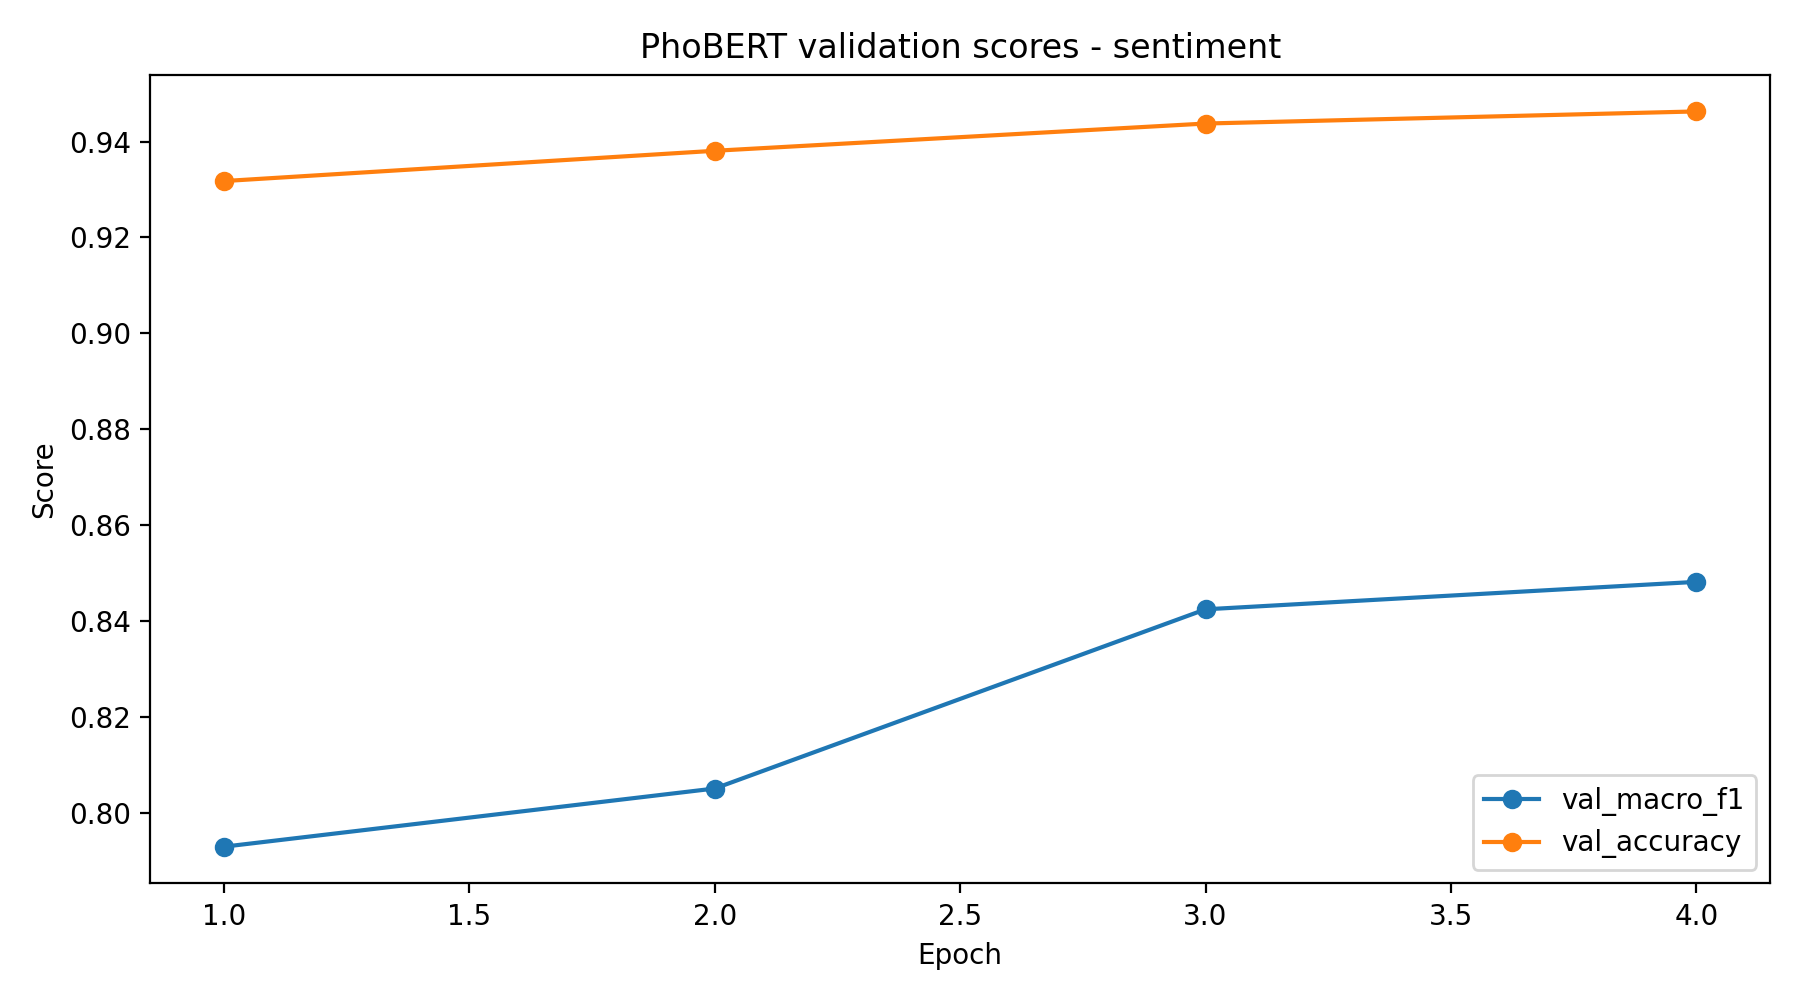

#### topic

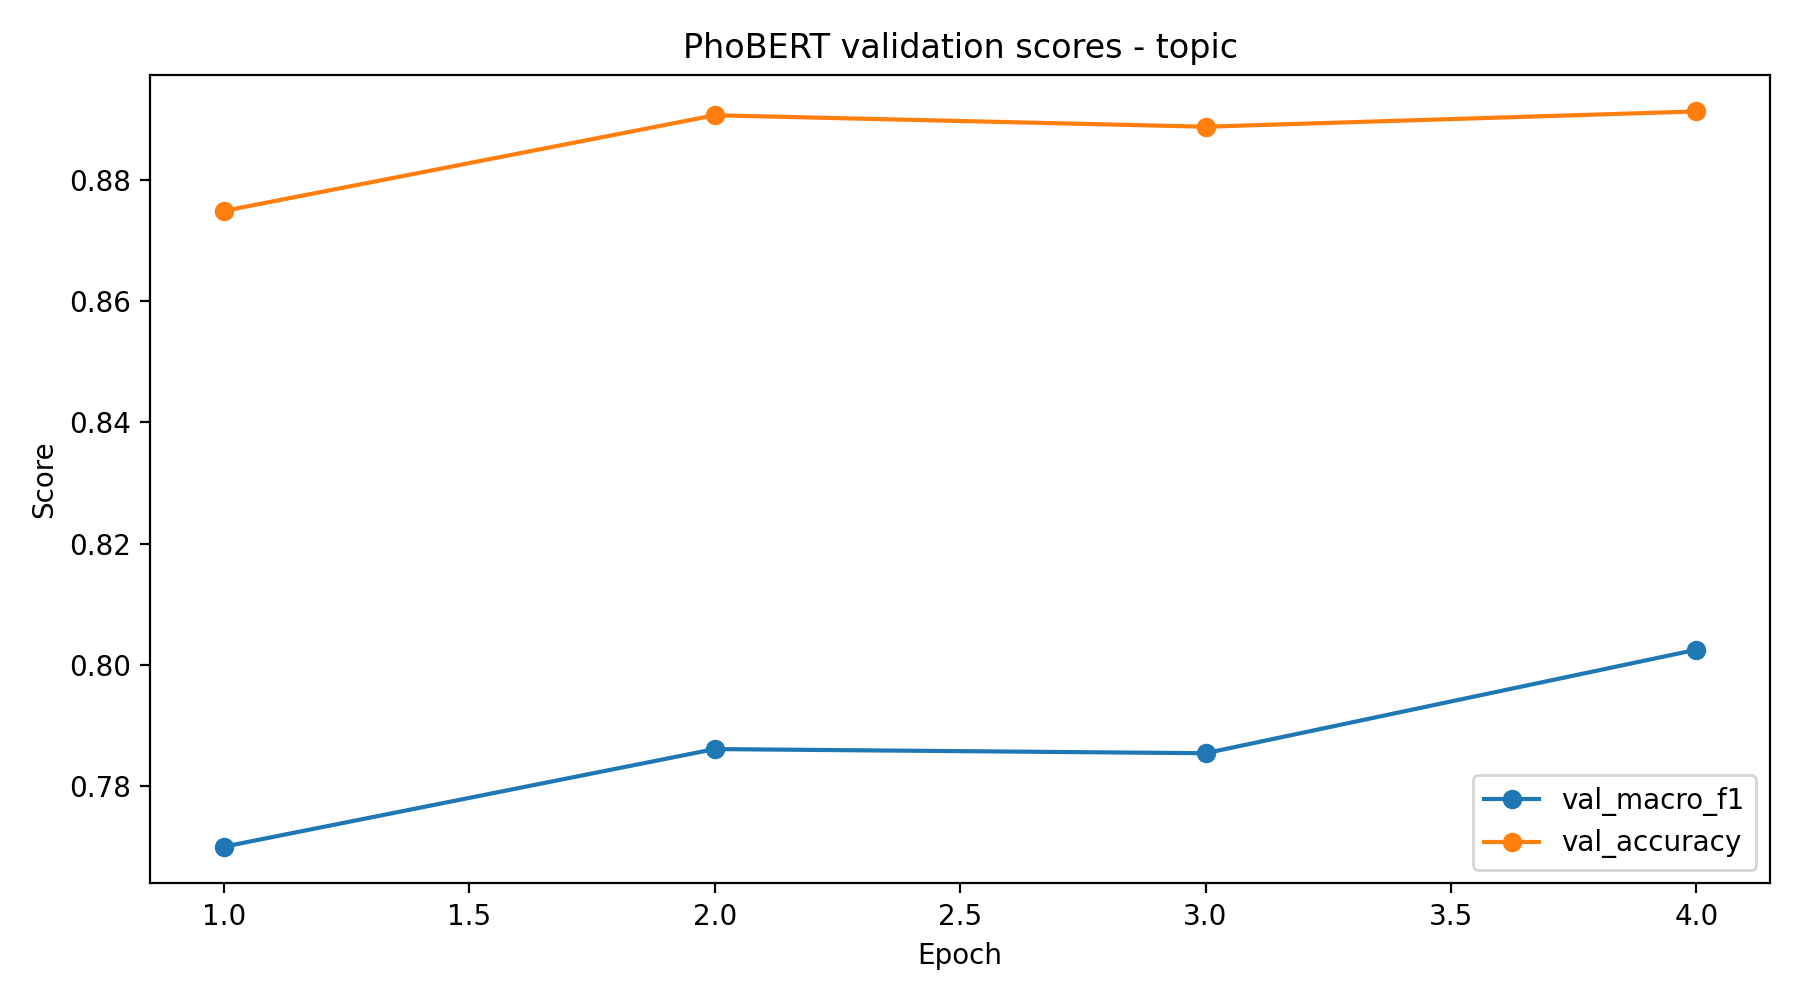

In [8]:
for task in ["sentiment", "topic"]:
    path = FIGURES_DIR / f"phobert_training_curve_{task}.png"
    if path.exists():
        display(Markdown(f"#### {task}"))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"⚠️ Missing figure: `{path}`"))

## 7. Clean per-class analysis

Mục tiêu: xem lớp nào còn yếu trên clean test.

In [9]:
summary_labels = {"accuracy", "macro avg", "weighted avg"}

clean_per_class = clean_report[
    ~clean_report["label"].isin(summary_labels)
].copy()

display(clean_per_class.sort_values(["task", "f1_score"]))

for task, group_df in clean_per_class.groupby("task"):
    weakest = group_df.sort_values("f1_score").iloc[0]
    display(Markdown(
        f"- Weakest clean class for **{task}**: `{weakest['label']}` "
        f"with F1 = **{weakest['f1_score']:.4f}**."
    ))

,task,model,variant,label,precision,recall,f1_score,support
1,sentiment,phobert,clean,neutral,0.625899,0.520958,0.568627,167.0
2,sentiment,phobert,clean,positive,0.947401,0.951572,0.949482,1590.0
0,sentiment,phobert,clean,negative,0.943357,0.957417,0.950335,1409.0
9,topic,phobert,clean,others,0.638655,0.477987,0.546763,159.0
7,topic,phobert,clean,training_program,0.776451,0.795455,0.785838,572.0
8,topic,phobert,clean,facility,0.924138,0.924138,0.924138,145.0
6,topic,phobert,clean,lecturer,0.938256,0.948908,0.943552,2290.0


- Weakest clean class for **sentiment**: `neutral` with F1 = **0.5686**.

- Weakest clean class for **topic**: `others` with F1 = **0.5468**.

## 8. Clean confusion matrices

### PhoBERT clean confusion matrix — sentiment

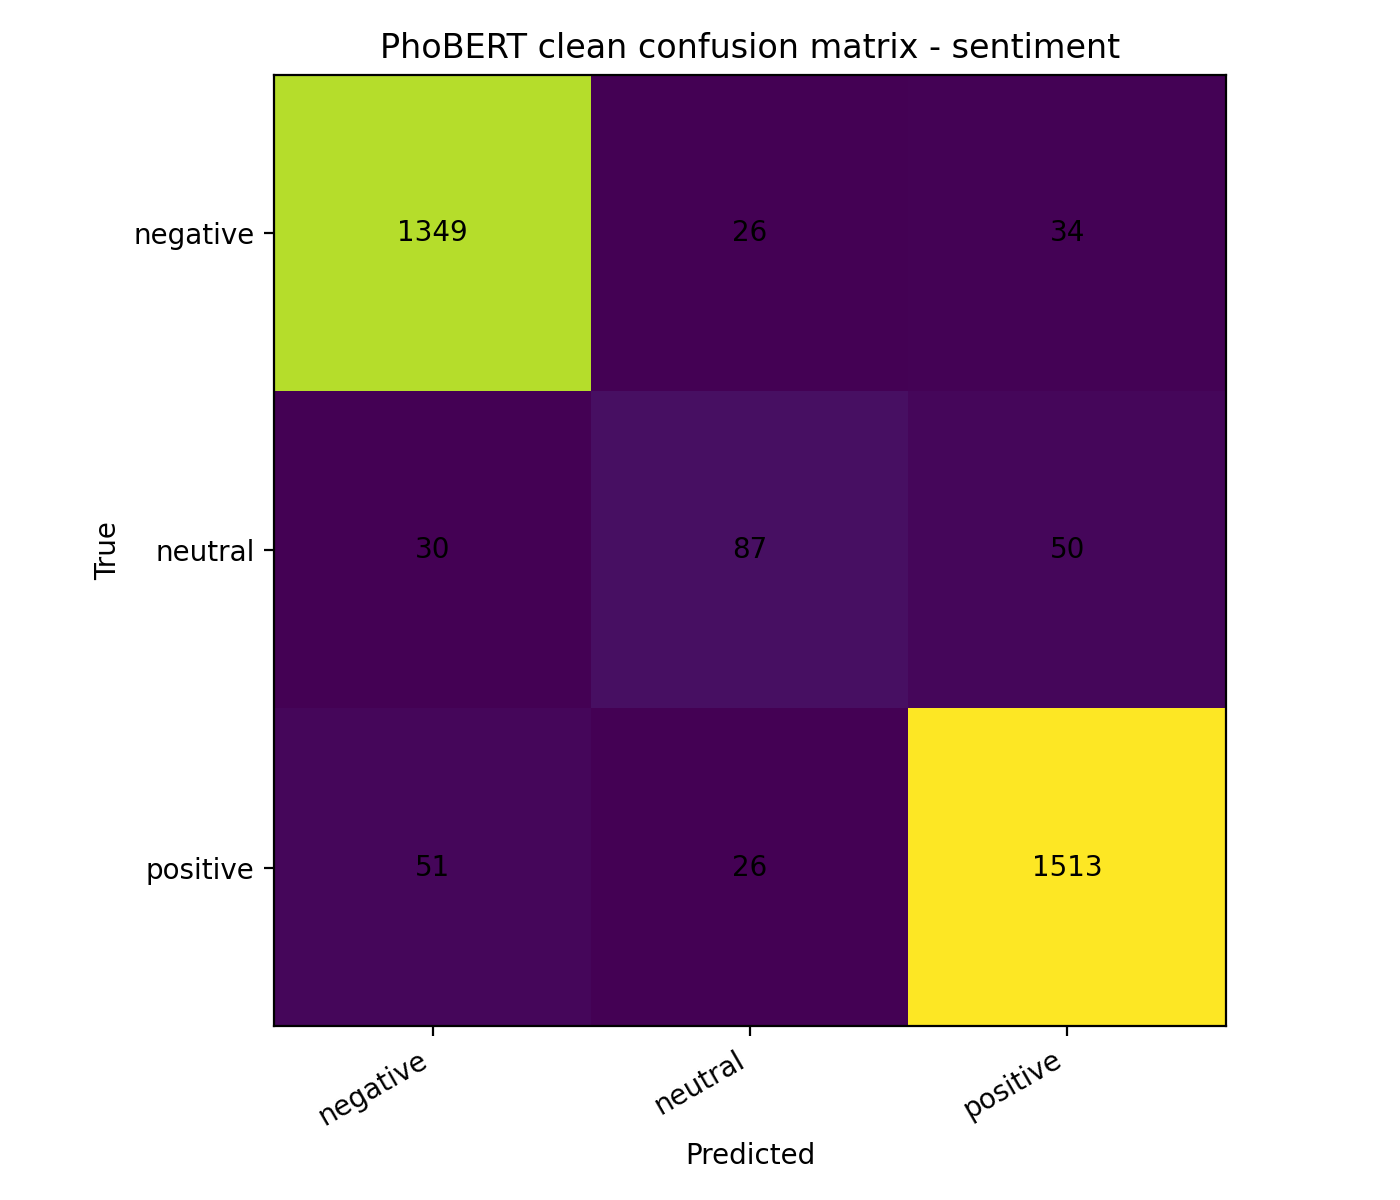

### PhoBERT clean confusion matrix — topic

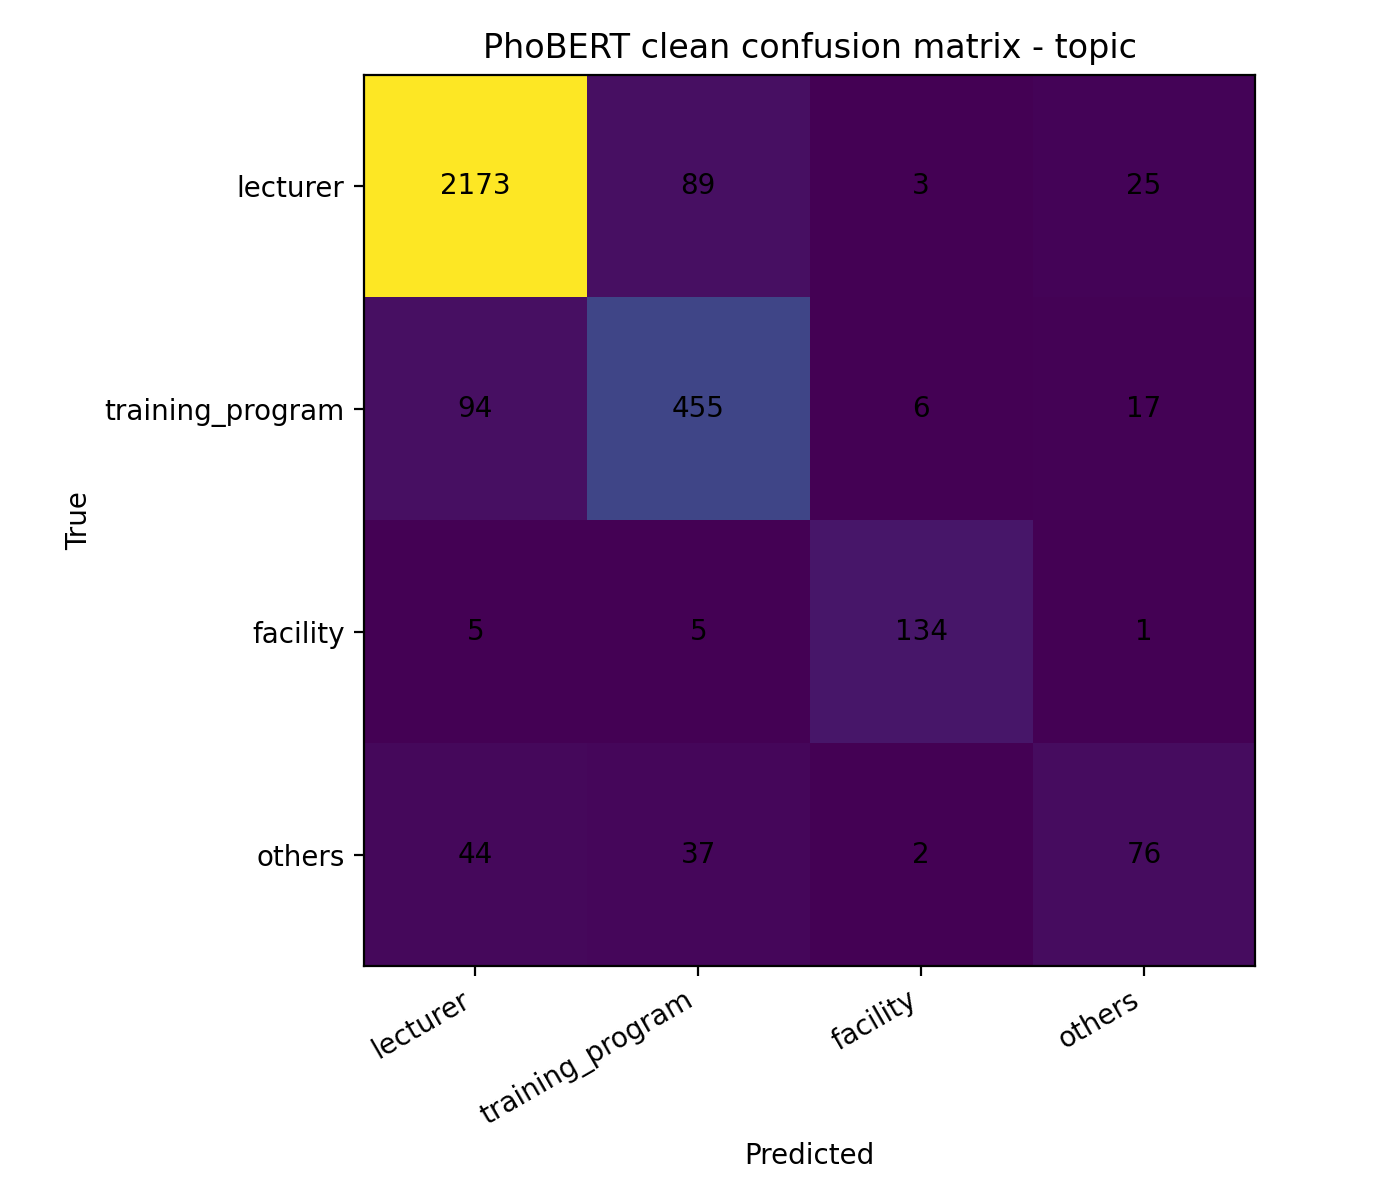

In [10]:
for task in ["sentiment", "topic"]:
    path = FIGURES_DIR / f"confusion_matrix_phobert_clean_{task}.png"
    if path.exists():
        display(Markdown(f"### PhoBERT clean confusion matrix — {task}"))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"⚠️ Missing confusion matrix: `{path}`"))

## 9. Robustness results

Mục tiêu: xem PhoBERT suy giảm bao nhiêu trên từng loại noise.

In [11]:
variant_order = [
    "clean",
    "typo_light",
    "typo_medium",
    "teencode_light",
    "mixed_light",
    "no_accent",
    "mixed_no_accent",
]

robustness_view = robustness_results.copy()
robustness_view["variant"] = pd.Categorical(
    robustness_view["variant"],
    categories=variant_order,
    ordered=True,
)
robustness_view = robustness_view.sort_values(["task", "variant"])

display(robustness_view)

,task,model,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1
0,sentiment,phobert,clean,clean,none,3166,0.931459,0.822815,0.929772
1,sentiment,phobert,typo_light,typo,light,3166,0.929248,0.820352,0.927437
2,sentiment,phobert,typo_medium,typo,medium,3166,0.927353,0.818815,0.926026
3,sentiment,phobert,teencode_light,teencode,light,3166,0.924826,0.814152,0.923594
4,sentiment,phobert,mixed_light,mixed,light,3166,0.921668,0.813839,0.920467
5,sentiment,phobert,no_accent,remove_diacritics,medium,3166,0.375237,0.339899,0.429524
6,sentiment,phobert,mixed_no_accent,mixed,medium,3166,0.371762,0.340462,0.430592
7,topic,phobert,clean,clean,none,3166,0.896399,0.800073,0.894241
8,topic,phobert,typo_light,typo,light,3166,0.893557,0.795476,0.891452
9,topic,phobert,typo_medium,typo,medium,3166,0.885344,0.786590,0.884517


## 10. Robustness drop

Mục tiêu: xác định loại nhiễu gây giảm Macro-F1 mạnh nhất.

In [12]:
drop_view = robustness_drop.copy()
drop_view["variant"] = pd.Categorical(
    drop_view["variant"],
    categories=variant_order,
    ordered=True,
)
drop_view = drop_view.sort_values(["task", "variant"])

display(drop_view)

worst_drop = (
    robustness_drop[robustness_drop["variant"] != "clean"]
    .sort_values(["task", "macro_f1_drop"], ascending=[True, False])
    .groupby("task")
    .head(1)
    .reset_index(drop=True)
)

display(Markdown("### Worst PhoBERT robustness drop by task"))
display(worst_drop[[
    "task",
    "variant",
    "clean_macro_f1",
    "variant_macro_f1",
    "macro_f1_drop",
    "macro_f1_relative_drop_percent",
]])

for _, row in worst_drop.iterrows():
    display(Markdown(
        f"- **{row['task']}**: worst variant = `{row['variant']}`, "
        f"Macro-F1 drop = **{row['macro_f1_drop']:.4f}** "
        f"({row['macro_f1_relative_drop_percent']:.2f}%)."
    ))

,task,model,variant,noise_type,noise_level,clean_accuracy,variant_accuracy,accuracy_drop,accuracy_relative_drop_percent,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent,clean_weighted_f1,variant_weighted_f1,weighted_f1_drop,weighted_f1_relative_drop_percent
0,sentiment,phobert,clean,clean,none,0.931459,0.931459,0.000000,0.0000,0.822815,0.822815,0.000000,0.0000,0.929772,0.929772,0.000000,0.0000
1,sentiment,phobert,typo_light,typo,light,0.931459,0.929248,0.002211,0.2374,0.822815,0.820352,0.002463,0.2993,0.929772,0.927437,0.002335,0.2511
2,sentiment,phobert,typo_medium,typo,medium,0.931459,0.927353,0.004106,0.4408,0.822815,0.818815,0.004000,0.4861,0.929772,0.926026,0.003746,0.4029
3,sentiment,phobert,teencode_light,teencode,light,0.931459,0.924826,0.006633,0.7121,0.822815,0.814152,0.008663,1.0528,0.929772,0.923594,0.006178,0.6645
4,sentiment,phobert,mixed_light,mixed,light,0.931459,0.921668,0.009791,1.0511,0.822815,0.813839,0.008976,1.0909,0.929772,0.920467,0.009305,1.0008
5,sentiment,phobert,no_accent,remove_diacritics,medium,0.931459,0.375237,0.556222,59.7151,0.822815,0.339899,0.482916,58.6907,0.929772,0.429524,0.500248,53.8033
6,sentiment,phobert,mixed_no_accent,mixed,medium,0.931459,0.371762,0.559697,60.0882,0.822815,0.340462,0.482353,58.6223,0.929772,0.430592,0.499180,53.6884
7,topic,phobert,clean,clean,none,0.896399,0.896399,0.000000,0.0000,0.800073,0.800073,0.000000,0.0000,0.894241,0.894241,0.000000,0.0000
8,topic,phobert,typo_light,typo,light,0.896399,0.893557,0.002842,0.3170,0.800073,0.795476,0.004597,0.5746,0.894241,0.891452,0.002789,0.3119
9,topic,phobert,typo_medium,typo,medium,0.896399,0.885344,0.011055,1.2333,0.800073,0.786590,0.013483,1.6852,0.894241,0.884517,0.009724,1.0874


### Worst PhoBERT robustness drop by task

,task,variant,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent
0,sentiment,no_accent,0.822815,0.339899,0.482916,58.6907
1,topic,no_accent,0.800073,0.186600,0.613473,76.6771


- **sentiment**: worst variant = `no_accent`, Macro-F1 drop = **0.4829** (58.69%).

- **topic**: worst variant = `no_accent`, Macro-F1 drop = **0.6135** (76.68%).

## 11. So sánh PhoBERT với baseline trên noisy variants

Mục tiêu: kiểm tra PhoBERT có bền hơn baseline truyền thống trên từng variant hay không.

Baseline robustness được lấy từ:

```text
outputs/tables/baseline_robustness_results.csv
```

In [13]:
baseline_robustness_path = TABLES_DIR / "baseline_robustness_results.csv"

if not baseline_robustness_path.exists():
    display(Markdown("⚠️ Missing `baseline_robustness_results.csv`. Skip noisy baseline comparison."))
else:
    baseline_robustness = pd.read_csv(baseline_robustness_path)

    best_baseline_by_variant = (
        baseline_robustness
        .sort_values(["task", "variant", "macro_f1"], ascending=[True, True, False])
        .groupby(["task", "variant"])
        .head(1)
        .reset_index(drop=True)
    )

    phobert_by_variant = robustness_results[
        ["task", "variant", "accuracy", "macro_f1", "weighted_f1"]
    ].rename(
        columns={
            "accuracy": "phobert_accuracy",
            "macro_f1": "phobert_macro_f1",
            "weighted_f1": "phobert_weighted_f1",
        }
    )

    compare_noisy = best_baseline_by_variant[
        ["task", "variant", "model", "accuracy", "macro_f1", "weighted_f1"]
    ].rename(
        columns={
            "model": "best_baseline_model",
            "accuracy": "baseline_accuracy",
            "macro_f1": "baseline_macro_f1",
            "weighted_f1": "baseline_weighted_f1",
        }
    ).merge(phobert_by_variant, on=["task", "variant"], how="inner")

    compare_noisy["macro_f1_gain"] = compare_noisy["phobert_macro_f1"] - compare_noisy["baseline_macro_f1"]
    compare_noisy["accuracy_gain"] = compare_noisy["phobert_accuracy"] - compare_noisy["baseline_accuracy"]
    compare_noisy["variant"] = pd.Categorical(compare_noisy["variant"], categories=variant_order, ordered=True)
    compare_noisy = compare_noisy.sort_values(["task", "variant"])

    display(compare_noisy)

    display(Markdown("### Variants where PhoBERT is worse than best baseline"))
    worse_than_baseline = compare_noisy[compare_noisy["macro_f1_gain"] < 0].copy()
    display(worse_than_baseline[[
        "task",
        "variant",
        "best_baseline_model",
        "baseline_macro_f1",
        "phobert_macro_f1",
        "macro_f1_gain",
    ]])

,task,variant,best_baseline_model,baseline_accuracy,baseline_macro_f1,baseline_weighted_f1,phobert_accuracy,phobert_macro_f1,phobert_weighted_f1,macro_f1_gain,accuracy_gain
0,sentiment,clean,tfidf_char_svm,0.875237,0.738784,0.876528,0.931459,0.822815,0.929772,0.084031,0.056222
5,sentiment,typo_light,tfidf_char_svm,0.873342,0.731545,0.874915,0.929248,0.820352,0.927437,0.088807,0.055906
6,sentiment,typo_medium,tfidf_char_svm,0.870499,0.731212,0.872558,0.927353,0.818815,0.926026,0.087603,0.056854
4,sentiment,teencode_light,tfidf_char_svm,0.869236,0.733458,0.871656,0.924826,0.814152,0.923594,0.080694,0.055590
1,sentiment,mixed_light,tfidf_char_svm,0.864498,0.724830,0.867596,0.921668,0.813839,0.920467,0.089009,0.057170
3,sentiment,no_accent,tfidf_char_svm,0.474416,0.414024,0.522812,0.375237,0.339899,0.429524,-0.074125,-0.099179
2,sentiment,mixed_no_accent,tfidf_char_svm,0.469678,0.411000,0.519813,0.371762,0.340462,0.430592,-0.070538,-0.097916
7,topic,clean,tfidf_word_svm,0.858497,0.750922,0.859847,0.896399,0.800073,0.894241,0.049151,0.037902
12,topic,typo_light,tfidf_word_svm,0.855338,0.749665,0.857454,0.893557,0.795476,0.891452,0.045811,0.038219
13,topic,typo_medium,tfidf_word_svm,0.848705,0.739693,0.851713,0.885344,0.786590,0.884517,0.046897,0.036639


### Variants where PhoBERT is worse than best baseline

,task,variant,best_baseline_model,baseline_macro_f1,phobert_macro_f1,macro_f1_gain
3,sentiment,no_accent,tfidf_char_svm,0.414024,0.339899,-0.074125
2,sentiment,mixed_no_accent,tfidf_char_svm,0.411000,0.340462,-0.070538
10,topic,no_accent,tfidf_char_svm,0.295702,0.186600,-0.109102
9,topic,mixed_no_accent,tfidf_char_svm,0.300282,0.187029,-0.113253


## 12. Per-class robustness: clean vs no_accent

Mục tiêu: kiểm tra lớp nào sụp mạnh nhất khi bỏ dấu.

In [14]:
per_class = robustness_class_report[
    ~robustness_class_report["label"].isin(summary_labels)
].copy()

clean_pc = per_class[per_class["variant"] == "clean"][
    ["task", "label", "precision", "recall", "f1_score"]
].rename(
    columns={
        "precision": "clean_precision",
        "recall": "clean_recall",
        "f1_score": "clean_f1",
    }
)

no_accent_pc = per_class[per_class["variant"] == "no_accent"][
    ["task", "label", "precision", "recall", "f1_score"]
].rename(
    columns={
        "precision": "no_accent_precision",
        "recall": "no_accent_recall",
        "f1_score": "no_accent_f1",
    }
)

pc_drop = clean_pc.merge(no_accent_pc, on=["task", "label"], how="inner")
pc_drop["f1_drop"] = pc_drop["clean_f1"] - pc_drop["no_accent_f1"]
pc_drop["relative_f1_drop_percent"] = pc_drop.apply(
    lambda row: 0.0 if row["clean_f1"] == 0 else round(row["f1_drop"] / row["clean_f1"] * 100, 4),
    axis=1,
)

pc_drop = pc_drop.sort_values(["task", "f1_drop"], ascending=[True, False])

display(pc_drop)

for task, group_df in pc_drop.groupby("task"):
    worst_class = group_df.sort_values("f1_drop", ascending=False).iloc[0]
    display(Markdown(
        f"- **{task}**: largest F1 drop under no_accent is `{worst_class['label']}` "
        f"with drop = **{worst_class['f1_drop']:.4f}**."
    ))

,task,label,clean_precision,clean_recall,clean_f1,no_accent_precision,no_accent_recall,no_accent_f1,f1_drop,relative_f1_drop_percent
0,sentiment,negative,0.943357,0.957417,0.950335,0.555147,0.214336,0.309268,0.641067,67.4570
1,sentiment,neutral,0.625899,0.520958,0.568627,0.080186,0.724551,0.144391,0.424236,74.6070
2,sentiment,positive,0.947401,0.951572,0.949482,0.687332,0.481132,0.566038,0.383445,40.3846
5,topic,facility,0.924138,0.924138,0.924138,0.288889,0.089655,0.136842,0.787296,85.1925
4,topic,training_program,0.776451,0.795455,0.785838,0.107143,0.068182,0.083333,0.702504,89.3956
3,topic,lecturer,0.938256,0.948908,0.943552,0.821333,0.268996,0.405263,0.538289,57.0492
6,topic,others,0.638655,0.477987,0.546763,0.065272,0.823899,0.120960,0.425802,77.8770


- **sentiment**: largest F1 drop under no_accent is `negative` with drop = **0.6411**.

- **topic**: largest F1 drop under no_accent is `facility` with drop = **0.7873**.

## 13. Per-class robustness across all variants

Mục tiêu: xem F1 của từng lớp biến động theo các loại noise.

In [15]:
per_class_view = per_class.copy()
per_class_view["variant"] = pd.Categorical(
    per_class_view["variant"],
    categories=variant_order,
    ordered=True,
)
per_class_view = per_class_view.sort_values(["task", "label", "variant"])

for task in per_class_view["task"].unique():
    display(Markdown(f"### {task}"))
    task_df = per_class_view[per_class_view["task"] == task]
    pivot = task_df.pivot_table(
        index="variant",
        columns="label",
        values="f1_score",
        observed=False,
    ).reindex(variant_order)
    display(pivot)

### sentiment

label,negative,neutral,positive
variant,,,
clean,0.950335,0.568627,0.949482
typo_light,0.948592,0.565789,0.946675
typo_medium,0.946032,0.564103,0.946311
teencode_light,0.944011,0.554140,0.944305
mixed_light,0.940383,0.560510,0.940625
no_accent,0.309268,0.144391,0.566038
mixed_no_accent,0.324734,0.141935,0.554717


### topic

label,facility,lecturer,others,training_program
variant,,,,
clean,0.924138,0.943552,0.546763,0.785838
typo_light,0.917808,0.942020,0.542857,0.779221
typo_medium,0.912892,0.936477,0.528814,0.768178
teencode_light,0.923611,0.936560,0.517483,0.763450
mixed_light,0.906574,0.934929,0.511945,0.754978
no_accent,0.136842,0.405263,0.120960,0.083333
mixed_no_accent,0.147368,0.389628,0.117701,0.093418


## 14. Kết luận Stage 6

Kết luận cần ghi nhận:

```text
1. PhoBERT vượt baseline truyền thống trên clean test ở cả sentiment và topic.
2. PhoBERT cải thiện rõ các lớp khó trên clean test, đặc biệt neutral và others.
3. PhoBERT ổn định với typo_light, typo_medium, teencode_light và mixed_light.
4. PhoBERT suy giảm rất mạnh trên no_accent và mixed_no_accent.
5. Trên no_accent, PhoBERT kém hơn TF-IDF char SVM ở cả hai task.
6. Điều này cho thấy PhoBERT không tự động bền vững với tiếng Việt mất dấu.
```

Diễn giải học thuật an toàn:

```text
Clean test đánh giá hiệu năng in-distribution.
Noisy test đánh giá robustness dưới nhiễu có kiểm soát.
Các noisy variants không được dùng để train hoặc chọn checkpoint.
```

In [16]:
display(Markdown("### Final PhoBERT clean results"))
display(clean_results)

display(Markdown("### Final PhoBERT worst drops"))
display(worst_drop[[
    "task",
    "variant",
    "clean_macro_f1",
    "variant_macro_f1",
    "macro_f1_drop",
    "macro_f1_relative_drop_percent",
]])

### Final PhoBERT clean results

,task,model,variant,accuracy,macro_f1,weighted_f1,best_epoch,best_val_macro_f1,train_seconds
0,sentiment,phobert,clean,0.931459,0.822815,0.929772,4,0.848147,469.23
1,topic,phobert,clean,0.896399,0.800073,0.894241,4,0.802489,468.99


### Final PhoBERT worst drops

,task,variant,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent
0,sentiment,no_accent,0.822815,0.339899,0.482916,58.6907
1,topic,no_accent,0.800073,0.186600,0.613473,76.6771
